In [20]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Reading the dataset
df = pd.read_csv(
    "data_Hw3_new.csv",
    sep=";",
    parse_dates=["Date"],
    date_format=lambda x: pd.to_datetime(x, format="%m/%d/%y %H:%M")
)
df .head()

,Date,WE_O3,AE_O3,WE_NO2,AE_NO2,Temp,RelHum,RefSt_O3
0,6/4/23 0:00,455.58,451.83,449.58,445.33,21.47,69.58,54.0
1,6/4/23 1:00,452.92,452.75,448.75,446.25,21.17,71.98,64.0
2,6/4/23 2:00,453.50,452.58,444.92,447.00,21.03,71.65,56.0
3,6/4/23 3:00,450.75,452.25,437.58,446.50,21.10,70.75,43.0
4,6/4/23 4:00,448.58,451.50,433.33,445.50,20.79,69.68,34.0


In [22]:
# Separate the information from Captor from the true values
# Captor data
X = df .iloc[:, 1:-1]
# True values
y = df .iloc[:, -1]

In [23]:
# Get the training Captor data, test Captor data, training true values and testing true values
# Use a deterministic random state for repeatable experiments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [24]:
param_grid = {'n_neighbors': list(range(1, 50))}
knr = KNeighborsRegressor(n_jobs=-1)

grid = GridSearchCV(knr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

print("Best params:",)
print("Best CV r2:", grid.best_score_)

best_model = grid.best_estimator_
# final evaluation on the untouched test set:
test_r2 = best_model.score(X_test, y_test)
print("Test R2:", test_r2)

Best params:
Best CV r2: 0.8189523667578733
Test R2: 0.8295051761277498


In [25]:
# Number of samples to use for training, first 4 weeks (24*7*4)
n_train = 672

X_train = X.iloc[:n_train]
X_test  = X.iloc[n_train:]

y_train = y.iloc[:n_train]
y_test  = y.iloc[n_train:]


In [26]:
param_grid = {'n_neighbors': list(range(1, 50))}
knr = KNeighborsRegressor(n_jobs=-1)

grid2 = GridSearchCV(knr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
grid2.fit(X_train, y_train)

print("Best params:",)
print("Best CV r2:", grid2.best_score_)

best_model2 = grid2.best_estimator_
# final evaluation on the untouched test set:
test_r2 = best_model2.score(X_test, y_test)
print("Test R2:", test_r2)

Best params:
Best CV r2: 0.6424797761004426
Test R2: 0.6203637311311003


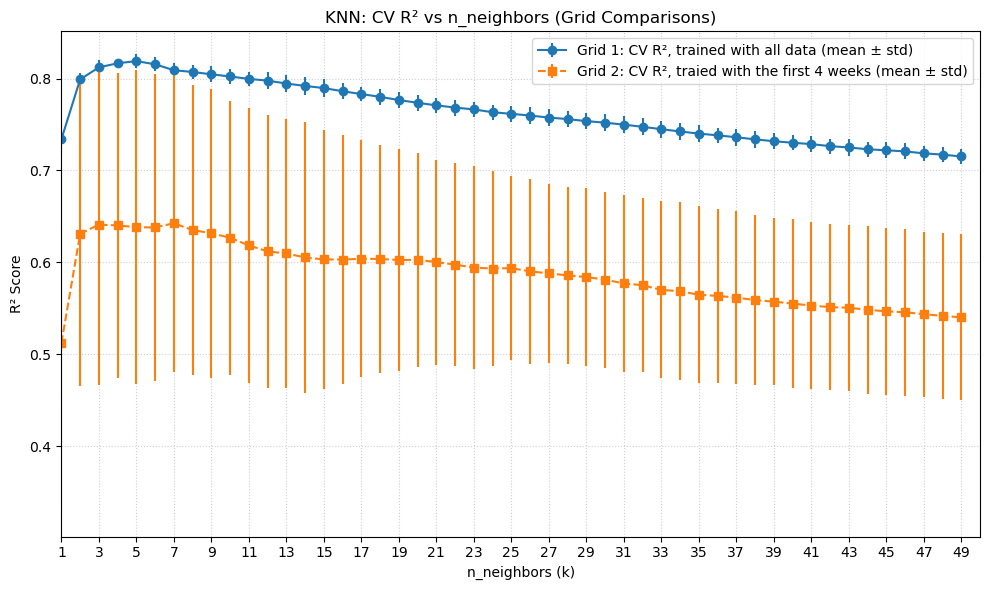

In [28]:
cv1 = grid.cv_results_
cv2 = grid2.cv_results_

# Extract values for grid 1
k_vals1 = np.array([int(k) for k in cv1['param_n_neighbors']])
mean_test1 = cv1['mean_test_score']
std_test1  = cv1['std_test_score']

# Extract values for grid 2
k_vals2 = np.array([int(k) for k in cv2['param_n_neighbors']])
mean_test2 = cv2['mean_test_score']
std_test2  = cv2['std_test_score']

plt.figure(figsize=(10,6))

# Grid 1
plt.errorbar(
    k_vals1, mean_test1, yerr=std_test1,
    fmt='o-', label='Grid 1: CV R², trained with all data (mean ± std)'
)

# Grid 2
plt.errorbar(
    k_vals2, mean_test2, yerr=std_test2,
    fmt='s--', label='Grid 2: CV R², traied with the first 4 weeks (mean ± std)'
)

plt.title("KNN: CV R² vs n_neighbors (Grid Comparisons)")
plt.xlabel("n_neighbors (k)")
plt.ylabel("R² Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(1, 51, 2))
plt.xlim(1, 50)
plt.legend()
plt.tight_layout()
plt.savefig("KNR_R2_graph.png", dpi=300)
plt.show()
